# Understanding SHAP in Probatus: Explainers and Explanations

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ing-bank/probatus/blob/master/docs/concepts/shap_explainer.ipynb)

This notebook explains how SHAP (SHapley Additive exPlanations) is implemented in Probatus and how to use it effectively. We'll cover:

1. What SHAP explainers and explanations are
2. Supported explainer types in Probatus
3. Key parameters affecting SHAP calculations
4. Accessing and using SHAP values in Probatus
5. Practical examples and best practices

In [1]:
%%capture
!pip install probatus

## SHAP Explainers and Explanations

SHAP (SHapley Additive exPlanations) is a unified approach to explain the output of any machine learning model. It connects game theory with local explanations using the classic Shapley values from game theory and their related extensions.

In Probatus, SHAP is implemented through two main objects from the `shap` library:

1. **Explainer**: The algorithm that computes SHAP values based on model type
2. **Explanation**: The actual SHAP values and related metadata

Let's first set up a basic example dataset and model:

In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Create synthetic data
X, y = make_classification(n_samples=1000, n_features=10, random_state=42)

# Create feature names
feature_names = [f"feature_{i}" for i in range(10)]
X = pd.DataFrame(X, columns=feature_names)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Supported SHAP Explainers in Probatus

Probatus supports several types of SHAP explainers, each optimized for different model types:

1. **TreeExplainer**: For tree-based models (Random Forest, XGBoost, LightGBM)
2. **LinearExplainer**: For linear models (Logistic Regression, Linear Regression, Ridge, Lasso)

Some explainer types are not currently supported in Probatus:
- KernelExplainer (slow for large datasets)
- DeepExplainer (for neural networks)
- SamplingExplainer (general-purpose but slow)

Probatus automatically selects the appropriate explainer type based on your model.

## Using SHAP in Probatus

The primary way to access SHAP functionality in Probatus is through the `calculate_shap_explanation` function from `probatus.utils.shap`. This function handles the creation of the appropriate explainer and returns the SHAP explanation:

In [3]:
from probatus.utils import calculate_shap_explanation

# Calculate SHAP values
shap_explanation = calculate_shap_explanation(
    model=model,
    X=X_test,
    return_explainer=False,
    random_state=42,
    sample_size=100,  # Number of background samples
    # Bigger sample size will result in more accurate SHAP values
    # but will also be slower
    approximate=False,  # Use exact SHAP values
    check_additivity=True,  # Verify SHAP values sum to model output
    # Smaller sample size will result in check_additivity being
    # more likely to fail, but the calculation will be faster
)

If you want to access both the explanation and the explainer (for reuse), you can set `return_explainer=True`:

In [4]:
# Get both explanation and explainer
shap_explanation, shap_explainer = calculate_shap_explanation(
    model=model, X=X_test, return_explainer=True, random_state=42
)

# The expected value represents the average model output
print(f"Expected value (baseline prediction): {shap_explainer.expected_value}")

Expected value (baseline prediction): [0.4369 0.5631]


## Key Parameters Affecting SHAP Calculations

When using SHAP in Probatus, several parameters significantly influence the calculation process:

### 1. `sample_size` (Default: 100)

This parameter controls how many data points are used to create the background dataset (masker) for SHAP calculations. It affects:

- **Computation speed**: Larger values slow down calculations
- **Accuracy**: Larger values may improve accuracy
- **Additivity**: Proper sampling helps ensure SHAP values add up correctly

Recommendations:
- For small datasets (< 1000 samples): Use ~20% of data
- For medium datasets: The default of 100 samples works well
- For large datasets: 100-500 samples is usually sufficient

### 2. `approximate` (Default: False)

For tree-based models, this parameter controls whether to use approximation methods:

- `False`: Calculates exact SHAP values (slower but more accurate)
- `True`: Uses approximation (much faster but less precise)

### 3. `check_additivity` (Default: False)

When enabled, SHAP verifies that the values add up to the model's prediction:

- `True`: Perform additivity check (may slow down calculation)
- `False`: Skip additivity check

Enabling this helps detect potential issues with the SHAP calculation.

### 4. `random_state` (Default: None)

For reproducible SHAP values, set this parameter to a fixed integer.

## SHAP in Probatus's High-Level Classes

Probatus provides several high-level classes that leverage SHAP for model interpretation and feature selection. One of the most popular is `ShapModelInterpreter`:

In [5]:
from probatus.model import ShapModelInterpreter

# Initialize the interpreter
shap_interpreter = ShapModelInterpreter(model, random_state=42)

# Fit and compute in one step
feature_importance = shap_interpreter.fit_compute(
    X_train,
    X_test,
    y_train,
    y_test,
    # Optional SHAP parameters
    approximate=False,
    check_additivity=True,
)

# Display feature importance
feature_importance

,mean_abs_shap_value_test,mean_abs_shap_value_train,mean_shap_value_test,mean_shap_value_train
feature_6,0.265784,0.271101,-0.023404,0.026884
feature_2,0.085592,0.086087,-0.005461,0.004113
feature_8,0.052544,0.056040,-0.004732,-0.003176
feature_0,0.025941,0.030356,-0.001297,-0.001926
feature_5,0.011392,0.012807,-0.001581,-0.002204
feature_9,0.009654,0.012361,-0.000229,-0.001913
feature_1,0.008534,0.011962,0.000295,-0.000755
feature_4,0.005837,0.008069,0.001002,0.002039
feature_7,0.005745,0.008043,-0.000432,-0.001644
feature_3,0.005340,0.007343,-0.000210,-0.000754


The `ShapModelInterpreter` provides various plotting capabilities:

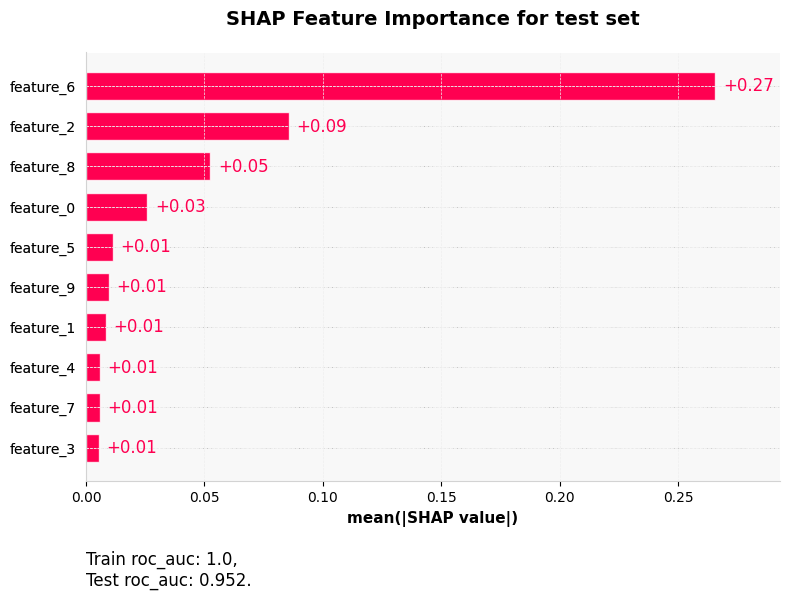

In [6]:
# Feature importance plot
shap_interpreter.plot("importance")

## Accessing SHAP Values Directly

After fitting `ShapModelInterpreter`, you can access the SHAP values directly:

In [7]:
# Access the raw SHAP explanation object for test data
shap_explanation_test = shap_interpreter.shap_explanation_test

# Access the processed SHAP values as a DataFrame
shap_values_test = shap_interpreter.shap_values_test

# Display the first few rows
shap_values_test.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9
521,-0.001752,-0.009182,-0.109026,-0.007471,-0.004799,-0.011280,-0.329164,-0.000972,0.018088,0.002458
737,0.046130,-0.001913,0.127665,-0.009828,-0.006929,0.001532,0.268732,-0.001328,-0.006110,-0.001050
740,-0.040147,0.002459,-0.059342,0.011842,0.001052,0.007326,0.075749,0.012188,-0.018711,-0.015516
660,-0.016639,-0.014143,0.078442,-0.003005,0.010913,0.009402,0.194852,0.007210,-0.037289,-0.012842
411,-0.029142,-0.004786,-0.091711,-0.001074,-0.001092,-0.009557,-0.361848,-0.000350,-0.068944,0.005403


## Creating Native SHAP Plots from Probatus Explanations

While Probatus provides convenient plotting methods through its high-level classes, you may want to create custom SHAP visualizations using the native SHAP library. The SHAP explanation objects returned by Probatus are compatible with SHAP's plotting functions.

First, let's import the SHAP visualization module:

In [8]:
import shap
import matplotlib.pyplot as plt

# Get SHAP explanation from Probatus
shap_explanation, _ = calculate_shap_explanation(model=model, X=X_test, return_explainer=True, random_state=42)

### SHAP Summary Plot

The summary plot shows the impact of each feature on the model output:

<Figure size 1000x800 with 0 Axes>

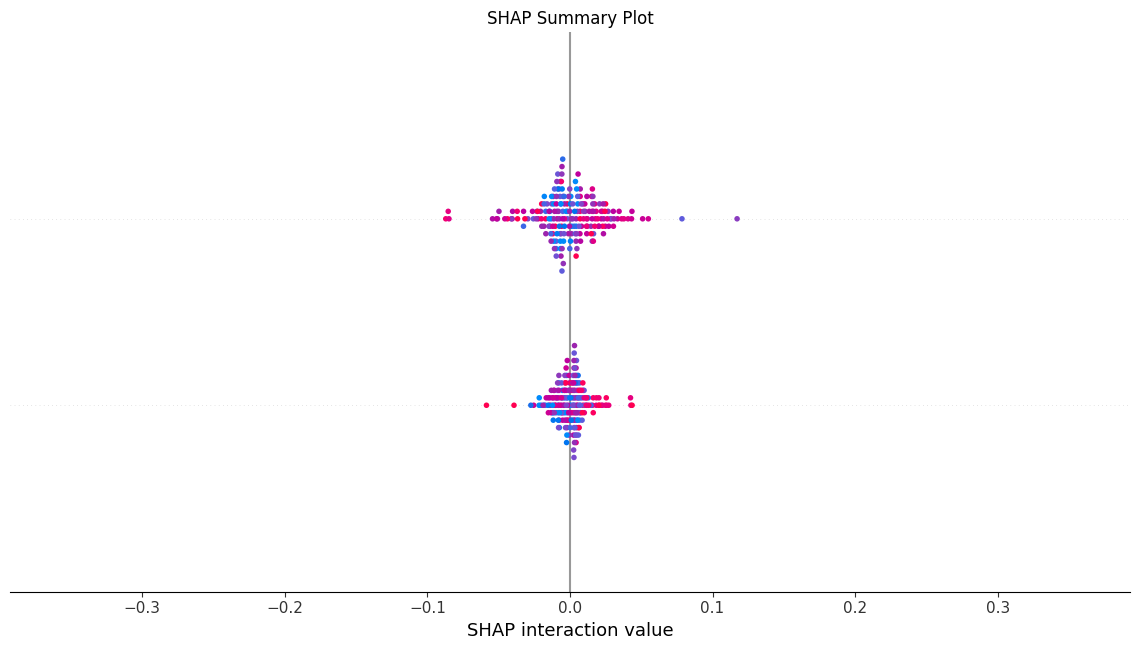

In [9]:
# Set the figure size
plt.figure(figsize=(10, 8))

# Create a SHAP summary plot
shap.summary_plot(shap_explanation, X_test, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

The ability to use Probatus's SHAP explanations with the native SHAP library gives you the best of both worlds: the simplified calculation process of Probatus and the flexible visualization options of SHAP.

## Conclusion

SHAP values provide powerful insights into model behavior and feature importance. In Probatus, they're implemented through a combination of explainer and explanation objects, with various utilities to make them easy to use.

The key parameters that affect SHAP calculations are:
- `sample_size`: Controls the background dataset size
- `approximate`: Toggles approximation for tree models
- `check_additivity`: Validates that SHAP values sum correctly
- `random_state`: Ensures reproducibility

By understanding these parameters and the available high-level classes, you can effectively use SHAP to interpret and improve your machine learning models.